I have succefully pulled and cleaned my air quality data from an open source API; which means it is now time to analyze the data and turn the insights into a dashsbaord that a client would pay money for.

The goal of the analysis is to: 	
    •	Identify major pollution spikes >25µg/m³
	•	Identify seasonal patterns
	•	Discuss possible emission sources

I have pulled data from March 2016 - May 2017
I will be anlazying how PM2.5 changes in Saskatoon within that timeframe
I am intrested in spikes in PM2.5 and then hopefully explaining those spikes based on the time of year it is

In [3]:
# Import libraries
import pandas as pd
import geopandas as gpd 
import matplotlib.pyplot as plt

In [4]:
# import data
df = pd.read_csv("/Users/dawsonconlon/Coding/Python/GIS_API/data_cleaning/clean_measurements.csv")
print(df.head())

                    datetime pollutant  units  measurement   latitude  \
0  2016-03-10 07:00:00+00:00      pm25  µg/m³         10.0  52.136055   
1  2016-03-10 08:00:00+00:00      pm25  µg/m³          7.0  52.136055   
2  2016-03-11 15:00:00+00:00      pm25  µg/m³         20.0  52.136055   
3  2016-03-11 16:00:00+00:00      pm25  µg/m³          8.0  52.136055   
4  2016-03-11 17:00:00+00:00      pm25  µg/m³          4.0  52.136055   

    longitude  
0 -106.662796  
1 -106.662796  
2 -106.662796  
3 -106.662796  
4 -106.662796  


In [5]:
def create_time_features(df):
    """
    Function to create time features from the datetime column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a datetime column.
    
    Returns:
    pandas.DataFrame: The input dataframe with new time features added.
    """
    
    #Convert datetime column to datetime format
    df["datetime"] = pd.to_datetime(df["datetime"])
    
    df["date"] = df["datetime"].dt.date
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df["days_of_week"] = df["datetime"].dt.day_name()
    
    return df


create_time_features(df)

,datetime,pollutant,units,measurement,latitude,longitude,date,year,month,day,hour,days_of_week
0,2016-03-10 07:00:00+00:00,pm25,µg/m³,10.0,52.136055,-106.662796,2016-03-10,2016,3,10,7,Thursday
1,2016-03-10 08:00:00+00:00,pm25,µg/m³,7.0,52.136055,-106.662796,2016-03-10,2016,3,10,8,Thursday
2,2016-03-11 15:00:00+00:00,pm25,µg/m³,20.0,52.136055,-106.662796,2016-03-11,2016,3,11,15,Friday
3,2016-03-11 16:00:00+00:00,pm25,µg/m³,8.0,52.136055,-106.662796,2016-03-11,2016,3,11,16,Friday
4,2016-03-11 17:00:00+00:00,pm25,µg/m³,4.0,52.136055,-106.662796,2016-03-11,2016,3,11,17,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2017-05-21 15:00:00+00:00,pm25,µg/m³,5.0,52.136055,-106.662796,2017-05-21,2017,5,21,15,Sunday
996,2017-05-21 16:00:00+00:00,pm25,µg/m³,5.0,52.136055,-106.662796,2017-05-21,2017,5,21,16,Sunday
997,2017-05-21 17:00:00+00:00,pm25,µg/m³,6.0,52.136055,-106.662796,2017-05-21,2017,5,21,17,Sunday
998,2017-05-21 18:00:00+00:00,pm25,µg/m³,5.0,52.136055,-106.662796,2017-05-21,2017,5,21,18,Sunday


In [6]:
#calculate summary statistics for the value column
def summary_statistics(df):
    """
    Function to calculate summary statistics for the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column.
    
    Returns:
    pandas.DataFrame: A dataframe containing the summary statistics for the value column.
    """
    
    summary_stats = df["measurement"].describe()
    
    return summary_stats

summary_stats = summary_statistics(df)
print(summary_stats)

count    1000.000000
mean        6.252000
std         5.693585
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        51.000000
Name: measurement, dtype: float64


On average between March 2016 - May 2017 the PM2.5 in Saskatoon is 6.25 µg/m³

Envrio and CLimate Change Canada says 5-6 µg/m³ is a moderate risk, you would expect this for saskatoon urban areas

7-10 µg/m³ = High risk
Greater than or equal to 10 = Very high


I can also see there is a max day of 51 meaning there was a day that was extremaly high 

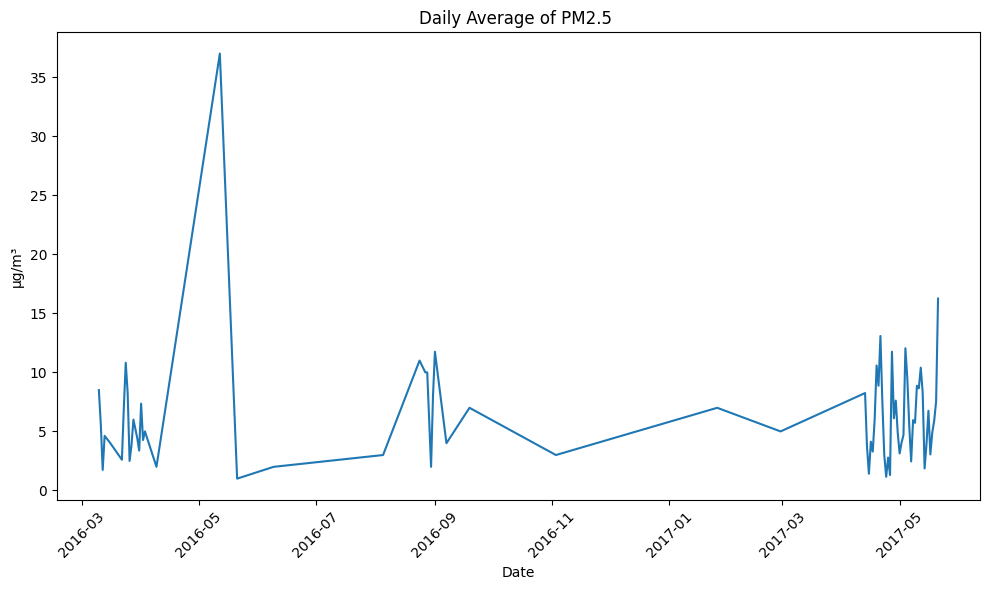

,date,measurement
0,2016-03-10,8.500000
1,2016-03-11,5.625000
2,2016-03-12,1.739130
3,2016-03-13,4.625000
4,2016-03-16,4.000000
...,...,...
67,2017-05-17,3.047619
68,2017-05-18,4.913043
69,2017-05-19,5.909091
70,2017-05-20,7.545455


In [7]:
def daily_average(df):
    """
    Function to calculate the daily average of the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column and a date column.
    
    Returns:
    pandas.DataFrame: A dataframe containing the daily average of the value column.
    plots a line graph of the daily average over time.
    """
    
    daily_avg = df.groupby("date")["measurement"].mean().reset_index()
    
    #plot daily average
    plt.figure(figsize=(10,6))
    plt.plot(daily_avg["date"], daily_avg["measurement"])
    plt.xlabel("Date")
    plt.ylabel("µg/m³")
    plt.title("Daily Average of PM2.5 ")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return daily_avg

daily_average(df)

I see big spikes of ups and downs followed by spans of stability

In [14]:
# detect pollutent events
def detect_pollutant_events(df, threshold = 25) :
    
    
    """
    Function to detect pollution events based on a specified threshold for the value column in the dataframe.
    
    Parameters:df (pandas.DataFrame): The input dataframe containing a value column and a datetime column.
    
    Returns: pandas.DataFrame: A dataframe containing the pollution events that exceed the specified threshold.
    Plots a line graph of the value column over time, highlighting the pollution events that exceed
    
    """
    
    pollution_event = df[df["measurement"] > threshold]

    
    return pollution_event

print(detect_pollutant_events(df))

                     datetime pollutant  units  measurement   latitude  \
158 2016-05-12 05:00:00+00:00      pm25  µg/m³         31.0  52.136055   
159 2016-05-12 08:00:00+00:00      pm25  µg/m³         43.0  52.136055   
171 2016-09-01 12:00:00+00:00      pm25  µg/m³         38.0  52.136055   
366 2017-04-21 17:00:00+00:00      pm25  µg/m³         29.0  52.136055   
449 2017-04-27 01:00:00+00:00      pm25  µg/m³         26.0  52.136055   
450 2017-04-27 02:00:00+00:00      pm25  µg/m³         51.0  52.136055   
455 2017-04-27 07:00:00+00:00      pm25  µg/m³         30.0  52.136055   
474 2017-04-28 12:00:00+00:00      pm25  µg/m³         27.0  52.136055   
599 2017-05-04 03:00:00+00:00      pm25  µg/m³         33.0  52.136055   
607 2017-05-04 12:00:00+00:00      pm25  µg/m³         27.0  52.136055   
695 2017-05-08 07:00:00+00:00      pm25  µg/m³         26.0  52.136055   
986 2017-05-21 06:00:00+00:00      pm25  µg/m³         31.0  52.136055   
987 2017-05-21 07:00:00+00:00      pm2

/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_58734/2953276662.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events["month"] = events["datetime"].dt.month


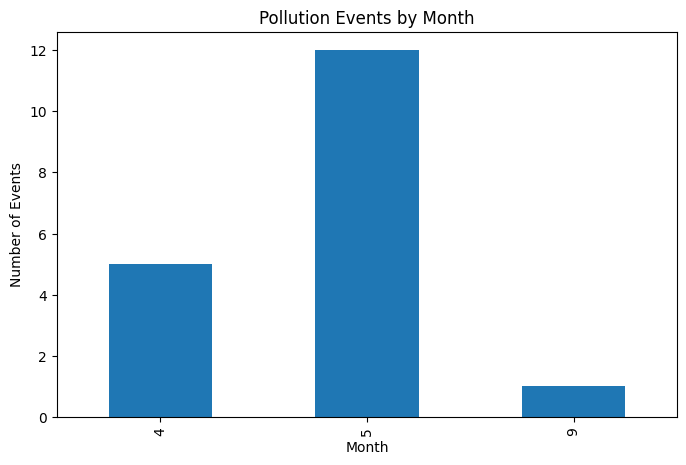

In [9]:
def plot_monthly_events(df, threshold=25):
    
    
    """
    Function to plot the number of pollution events by month based on a specified threshold for the value column in the dataframe.
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column and a datetime column.
    threshold (float): The threshold value for detecting pollution events. Default is 25.

    returns:
    None: This function does not return any value but plots a bar graph of the number of pollution
    
    """

    events = detect_pollutant_events(df, threshold)

    events["month"] = events["datetime"].dt.month

    monthly_counts = events.groupby("month").size()

    plt.figure(figsize=(8,5))

    monthly_counts.plot(kind="bar")

    plt.title("Pollution Events by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Events")

    plt.show()
    
plot_monthly_events(df)

18 total majore polllution events and May and June account for nearly all of them

In [16]:
# How many total pollution events were detected?
print(f"Total pollution events detected: {len(detect_pollutant_events(df))}")

Total pollution events detected: 18


In [ ]:

# monthly average
monthly_avg = df.groupby("month")["measurement"].mean()
print(monthly_avg)

month
1     7.000000
2     5.000000
3     5.062500
4     6.013228
5     6.715789
6     2.000000
8     7.333333
9     9.666667
11    3.000000
Name: measurement, dtype: float64


In [ ]:

def detect_pollution_episodes(df, threshold=25):
    """
    Group consecutive pollution measurements into single events
    """

    df = df.sort_values("datetime").copy()

    df["is_event"] = df["measurement"] > threshold

    # create event groups whenever pollution status changes
    df["event_group"] = (df["is_event"] != df["is_event"].shift()).cumsum()

    # keep only pollution groups
    events = df[df["is_event"]]

    return events

In [ ]:
def calculate_event_durations(df, threshold=25):
    
    """
    Function to calculate the duration of pollution events based on a specified threshold for the value column in the dataframe.
    
    Parameters:
    df (pandas.DataFrame): The input dataframe containing a value column and a datetime column.
    threshold (float): The threshold value for detecting pollution events. Default is 25.

    Returns:
pandas.DataFrame: A dataframe containing the summary of pollution events, including start time, end time, maximum value, number of observations, and duration in hours for each event.

    
    """
    

    events = detect_pollution_episodes(df, threshold)

    event_summary = (
        events.groupby("event_group")
        .agg(
            start_time=("datetime", "min"),
            end_time=("datetime", "max"),
            max_pm25=("measurement", "max"),
            observations=("measurement", "count")
        )
        .reset_index(drop=True)
    )

    event_summary["duration_hours"] = (
        event_summary["end_time"] - event_summary["start_time"]
    ).dt.total_seconds() / 3600

    return event_summary

In [ ]:
event_summary = calculate_event_durations(df)

average_duration = event_summary["duration_hours"].mean()

longest_event = event_summary["duration_hours"].max()

print("Average event duration:", average_duration, "hours")

print("Longest event:", longest_event, "hours")

Average event duration: 1.0 hours
Longest event: 6.0 hours


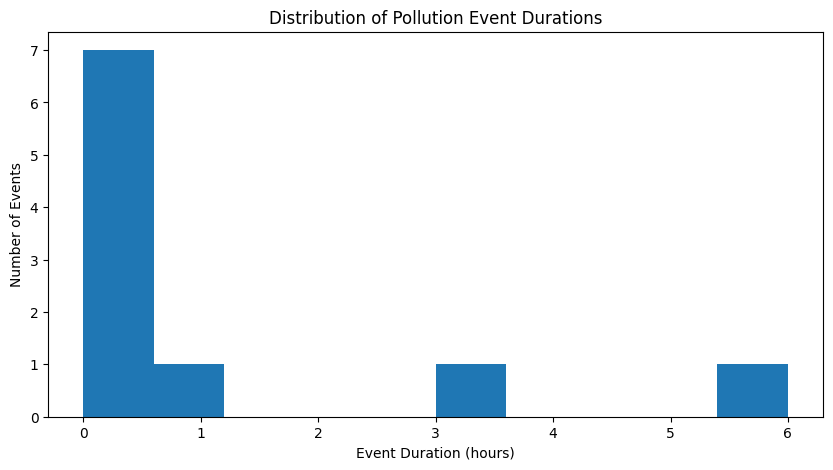

In [ ]:

def plot_event_durations(event_summary):
    
    """
    function to plot the distribution of pollution event durations based on the event summary dataframe.

    Parameters:
    event_summary (pandas.DataFrame): A dataframe containing the summary of pollution events, including duration

    Returns:
    None: This function does not return any value but plots a histogram of the distribution of pollution event durations

    """


    plt.figure(figsize=(10,5))

    plt.hist(event_summary["duration_hours"], bins=10)

    plt.xlabel("Event Duration (hours)")
    plt.ylabel("Number of Events")
    plt.title("Distribution of Pollution Event Durations")

    plt.show()
    
    plot_event_durations(event_summary)

On average these pollution evets are lasting less than a hour wiht the longest lasting 6 hours.

I have air quality averge,
 monthly average 
 average duration
 longest duration
 most common months with spikes

 This should be good enough for a inital dashbaord to present to millenium.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import dash
from dash import dcc, html
import plotly.express as px
import plotly.graph_objects as go


# LOAD DATA


df = pd.read_csv("/Users/dawsonconlon/Coding/Python/GIS_API/data_cleaning/clean_measurements.csv")
df["datetime"] = pd.to_datetime(df["datetime"])



# ANALYSIS FUNCTIONS


def detect_pollutant_events(df, threshold=25):

    events = df[df["measurement"] > threshold]

    return events


def summary_statistics(df):

    return df["measurement"].describe()


def plot_monthly_events(df, threshold=25):

    events = detect_pollutant_events(df, threshold)

    events["month"] = events["datetime"].dt.month

    monthly_counts = events.groupby("month").size().reset_index(name="count")

    return monthly_counts


def calculate_event_durations(df, threshold=25):

    df = df.sort_values("datetime").copy()

    df["event"] = df["measurement"] > threshold
    df["group"] = (df["event"] != df["event"].shift()).cumsum()

    events = df[df["event"]]

    summary = (
        events.groupby("group")
        .agg(
            start=("datetime","min"),
            end=("datetime","max"),
            observations=("measurement","count"),
            max_pm25=("measurement","max")
        )
    )

    summary["duration_hours"] = (summary["end"] - summary["start"]).dt.total_seconds()/3600

    return summary



# RUN ANALYSIS


events = detect_pollutant_events(df)
stats = summary_statistics(df)
monthly_counts = plot_monthly_events(df)
event_summary = calculate_event_durations(df)

mean_pm25 = round(stats["mean"],2)
max_pm25 = round(stats["max"],2)
min_pm25 = round(stats["min"],2)
total_events = len(events)

average_duration = round(event_summary["duration_hours"].mean(),2)
longest_event = round(event_summary["duration_hours"].max(),2)



# CREATE DASH FIGURES


def create_timeseries():

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df["datetime"],
            y=df["measurement"],
            mode="lines",
            name="PM2.5"
        )
    )

    fig.add_trace(
        go.Scatter(
            x=events["datetime"],
            y=events["measurement"],
            mode="markers",
            name="Pollution Events"
        )
    )

    fig.add_hline(y=25)

    fig.update_layout(
        title="PM2.5 Concentration Over Time",
        xaxis_title="Date",
        yaxis_title="PM2.5 (µg/m³)",
        height=500
    )

    return fig


def create_monthly_plot():

    fig = px.bar(
        monthly_counts,
        x="month",
        y="count",
        title="Pollution Events by Month"
    )

    return fig


def create_duration_histogram():

    fig = px.histogram(
        event_summary,
        x="duration_hours",
        nbins=10,
        title="Distribution of Pollution Event Durations"
    )

    return fig


timeseries_fig = create_timeseries()
monthly_fig = create_monthly_plot()
duration_fig = create_duration_histogram()



# DASHBOARD LAYOUT


app = dash.Dash(__name__)

app.layout = html.Div(

    style={"fontFamily":"Arial","margin":"40px"},

    children=[

        html.H1(
            "Saskatoon Air Quality Dashboard",
            style={"textAlign":"center"}
        ),

        html.Br(),

        # KPI ROW
        html.Div(

            style={"display":"flex","justifyContent":"space-between"},

            children=[

                html.Div([
                    html.H3("Mean PM2.5"),
                    html.H2(f"{mean_pm25} µg/m³")
                ], style={"width":"16%","textAlign":"center","border":"1px solid lightgray","padding":"15px"}),

                html.Div([
                    html.H3("Max PM2.5"),
                    html.H2(f"{max_pm25} µg/m³")
                ], style={"width":"16%","textAlign":"center","border":"1px solid lightgray","padding":"15px"}),

                html.Div([
                    html.H3("Min PM2.5"),
                    html.H2(f"{min_pm25} µg/m³")
                ], style={"width":"16%","textAlign":"center","border":"1px solid lightgray","padding":"15px"}),

                html.Div([
                    html.H3("Pollution Events"),
                    html.H2(total_events)
                ], style={"width":"16%","textAlign":"center","border":"1px solid lightgray","padding":"15px"}),

                html.Div([
                    html.H3("Avg Event Duration"),
                    html.H2(f"{average_duration} hrs")
                ], style={"width":"16%","textAlign":"center","border":"1px solid lightgray","padding":"15px"}),

                html.Div([
                    html.H3("Longest Event"),
                    html.H2(f"{longest_event} hrs")
                ], style={"width":"16%","textAlign":"center","border":"1px solid lightgray","padding":"15px"}),

            ]
        ),

        html.Br(),
        html.Br(),

        # MAIN GRAPH
        dcc.Graph(figure=timeseries_fig),

        html.Br(),

        # SECOND ROW
        html.Div(

            style={"display":"flex","gap":"30px"},

            children=[

                html.Div(
                    dcc.Graph(figure=monthly_fig),
                    style={"width":"50%"}
                ),

                html.Div(
                    dcc.Graph(figure=duration_fig),
                    style={"width":"50%"}
                )

            ]
        )

    ]
)


# -----------------------
# RUN DASH SERVER
# -----------------------

if __name__ == "__main__":
    app.run(debug=True)

/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_55341/2818675057.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events["month"] = events["datetime"].dt.month


This is a decent rough first dashbaord and anlysis, I worked on it for 4 days while having another full time job so it is not perfect but it is insightfull and functinal. 

On averge the PM2.5 in Saskatoon is 6.25µg/m³. This is a moderate level and normal for an urban agriculture city. The data is just over a years worth of collection and within that time there was 18 sensor readings where there was a PM2.5 greater than 25µg/m³. These are high risk events that ussally happen in April and May and last less than a hour, though it has been recorded where one of these events occured for more than 5 hours. The worst reocrded air quality was recorded on April 27th 2017 with a max of 51µg/m³, that day had 3 other readings 
above 25µg/m³. 

This pipeline can be modified easily to analyze other PM2.5 thresholds such as days when air quality is >10µg/m³

Seasonal trends: April and May have shown to be the months when Saskatoon is at high risk of a major air quality event why?
    Wildfire season starts in Sask on April 1st 
    Spring agriculture actiivity
    Unstable atmospheric mixing
    Road dust after winter
    Long range trnasport of pollution


So it does make sense that we are seeing bad air quality in these months but I would have expected to also see some events in mid summer as wildfires can be fearce at that time.

What happend May 12 2016 7 April 27th 2017:
    There is not a ton of information on the air quality spikes that occured during these times and most public sask air quality data websites dont have data pre 2020, so I am having trouble validating these results with external news and data but these spikes are most likley due to wildfrie smoke rolling into Sask from fires that could have happend in the states or Canada.




